# PCA — Exploratory Data Analysis

## Fashion-MNIST Dataset
- **Source**: Zalando Research — 28×28 grayscale images of clothing/footwear
- **Samples**: 70,000 (60,000 train + 10,000 test, pre-split)
- **Features**: 784 (28×28 flattened pixels, values 0-255)
- **Classes**: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
- **Task**: Dimensionality reduction — compress 784 features while retaining maximum variance

## Why PCA?
- First dimensionality reduction technique in the project (all previous models were classification/clustering)
- 784 features has significant redundancy — adjacent pixels are highly correlated
- PCA finds orthogonal directions of maximum variance, enabling lossy compression
- Evaluated both intrinsically (explained variance, reconstruction error) and extrinsically (downstream classifier accuracy)

## Goals
1. Understand the raw data distribution and structure
2. Identify pixel-level redundancy that PCA can exploit
3. Preview eigenvalue decay to estimate compression potential
4. Inform preprocessing decisions for the pipeline notebooks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


# Step 1: Load Fashion-MNIST raw data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Bag", "Sneaker", "Ankle boot"
]

print("=" * 60)
print("Fashion-MNIST — Raw Data Summary")
print("=" * 60)
print(f"[1/1] Train: {X_train.shape}, Test: {X_test.shape}")
print(f"       Labels: {y_train.shape}, {y_test.shape}")
print(f"       Dtype: {X_train.dtype}, Pixel range: [{X_train.min()}, {X_train.max()}]")
print(f"       Classes: {len(CLASS_NAMES)} — {', '.join(CLASS_NAMES)}")
print(f"       Total samples: {len(X_train) + len(X_test):,}")

Fashion-MNIST — Raw Data Summary
[1/1] Train: (60000, 28, 28), Test: (10000, 28, 28)
       Labels: (60000,), (10000,)
       Dtype: uint8, Pixel range: [0, 255]
       Classes: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
       Total samples: 70,000


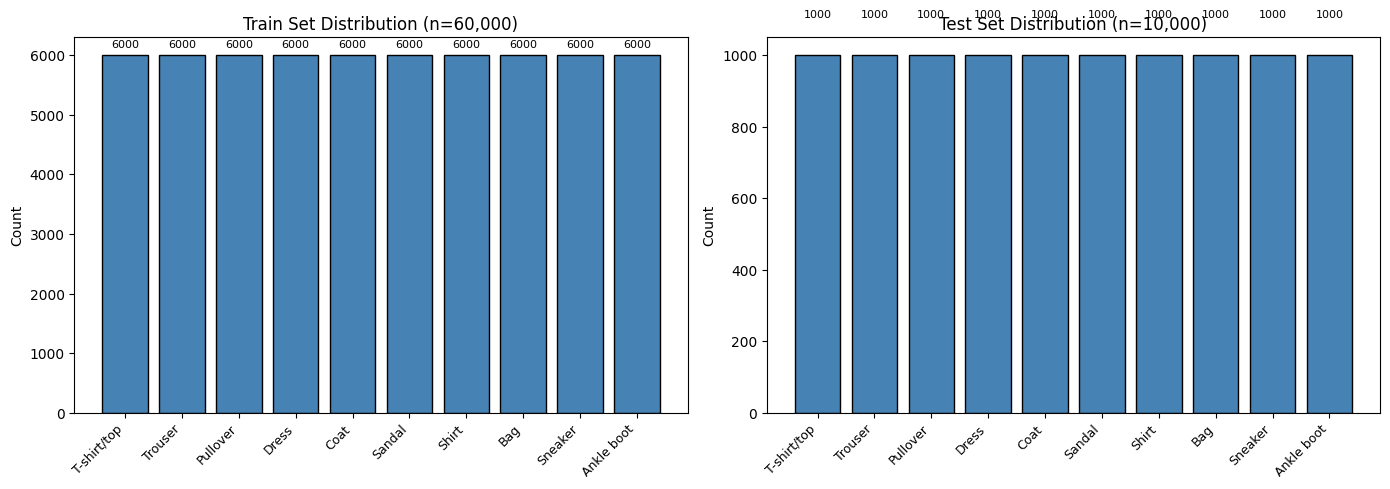

[2/2] Class balance check
  Train — min: 6000, max: 6000, ratio: 1.00x
  Test  — min: 1000, max: 1000, ratio: 1.00x


In [2]:
# Step 2: Class distribution
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train", "Test"]):
    bars = ax.bar(range(10), counts, color="steelblue", edgecolor="black")
    ax.set_xticks(range(10))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Count")
    ax.set_title(f"{title} Set Distribution (n={counts.sum():,})")
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                str(count), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print("=" * 60)
print("[2/2] Class balance check")
print("=" * 60)
print(f"  Train — min: {train_counts.min()}, max: {train_counts.max()}, "
      f"ratio: {train_counts.max() / train_counts.min():.2f}x")
print(f"  Test  — min: {test_counts.min()}, max: {test_counts.max()}, "
      f"ratio: {test_counts.max() / test_counts.min():.2f}x")

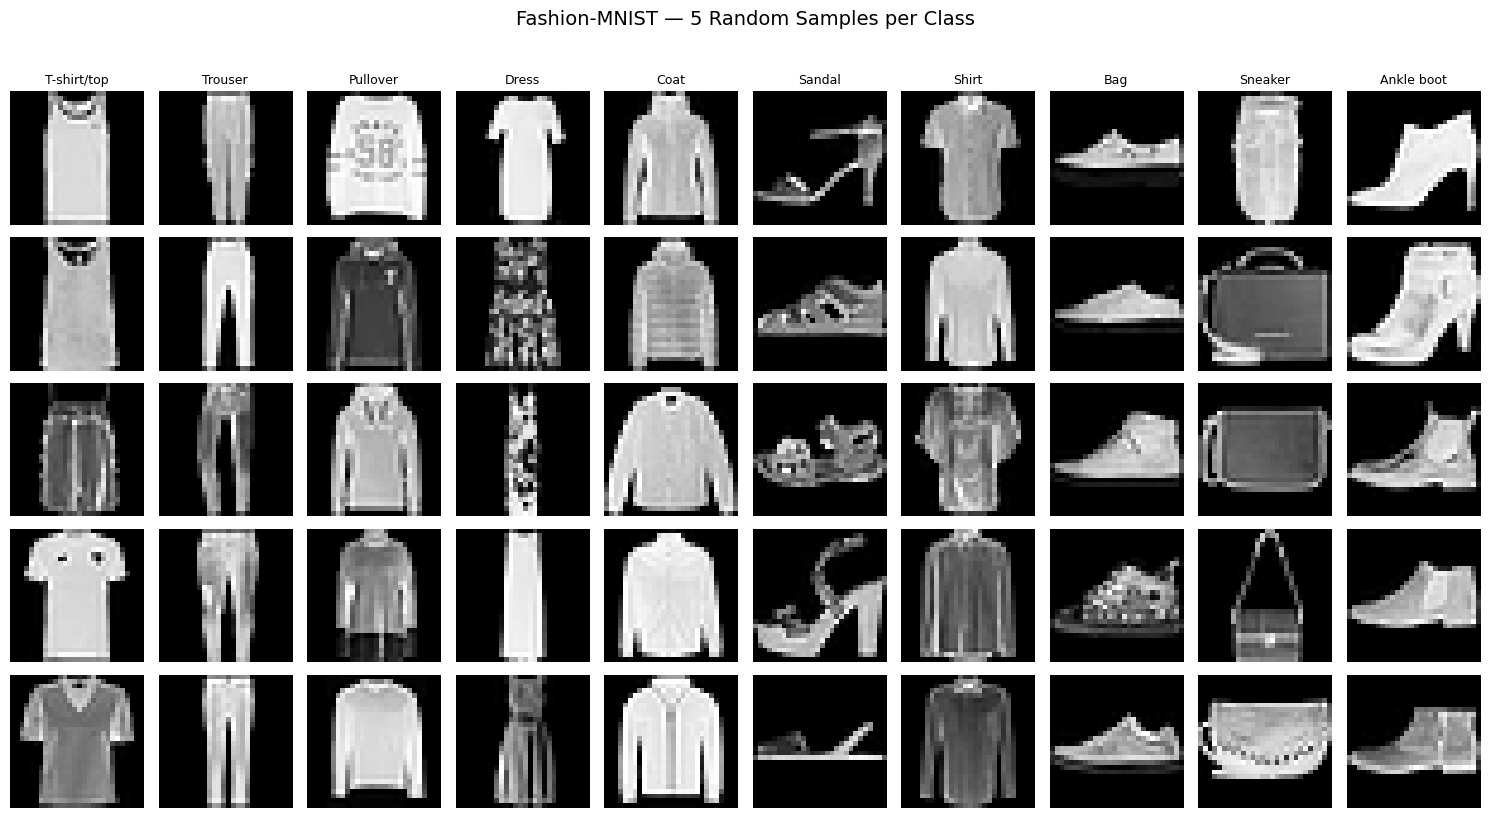

In [3]:
# Step 3: Sample image grid (5 samples per class)
fig, axes = plt.subplots(5, 10, figsize=(15, 8))

np.random.seed(113)
for col, cls in enumerate(range(10)):
    # Randomly pick 5 samples from this class
    indices = np.where(y_train == cls)[0]
    chosen = np.random.choice(indices, size=5, replace=False)
    for row, idx in enumerate(chosen):
        axes[row, col].imshow(X_train[idx], cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[cls], fontsize=9)

plt.suptitle("Fashion-MNIST — 5 Random Samples per Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

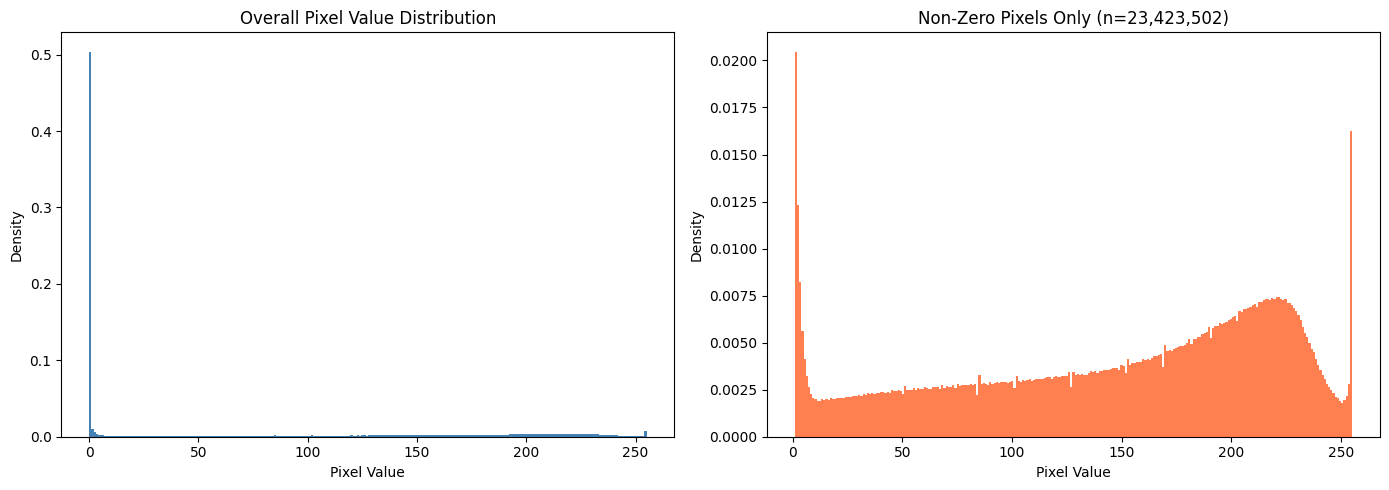

[4/4] Pixel statistics
  Total pixels: 47,040,000
  Zero pixels:  50.2%
  Non-zero mean: 146.5, std: 74.2
  Overall mean:  72.9, std: 90.0


In [4]:
# Step 4: Pixel value distribution

# Flatten all train images to get pixel value histogram
all_pixels = X_train.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(all_pixels, bins=256, range=(0, 255), color="steelblue",
             edgecolor="none", density=True)
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Density")
axes[0].set_title("Overall Pixel Value Distribution")

# Non-zero pixels only (ignore background)
nonzero_pixels = all_pixels[all_pixels > 0]
axes[1].hist(nonzero_pixels, bins=255, range=(1, 255), color="coral",
             edgecolor="none", density=True)
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Non-Zero Pixels Only (n={len(nonzero_pixels):,})")

plt.tight_layout()
plt.show()

zero_pct = (all_pixels == 0).sum() / len(all_pixels) * 100
print("=" * 60)
print("[4/4] Pixel statistics")
print("=" * 60)
print(f"  Total pixels: {len(all_pixels):,}")
print(f"  Zero pixels:  {zero_pct:.1f}%")
print(f"  Non-zero mean: {nonzero_pixels.mean():.1f}, std: {nonzero_pixels.std():.1f}")
print(f"  Overall mean:  {all_pixels.mean():.1f}, std: {all_pixels.std():.1f}")

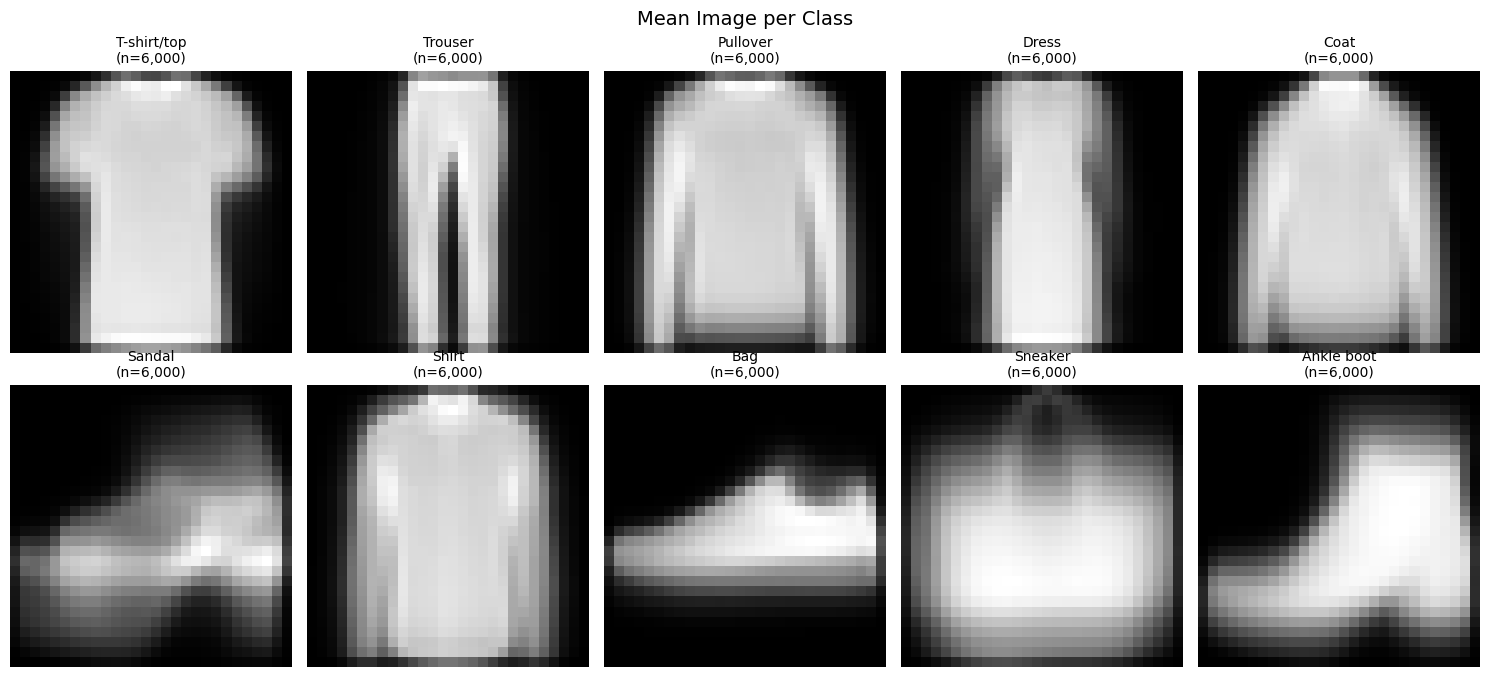

In [5]:
# Step 5: Mean image per class

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for cls, ax in enumerate(axes.flat):
    mask = y_train == cls
    mean_img = X_train[mask].mean(axis=0)
    ax.imshow(mean_img, cmap="gray")
    ax.set_title(f"{CLASS_NAMES[cls]}\n(n={mask.sum():,})", fontsize=10)
    ax.axis("off")

plt.suptitle("Mean Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

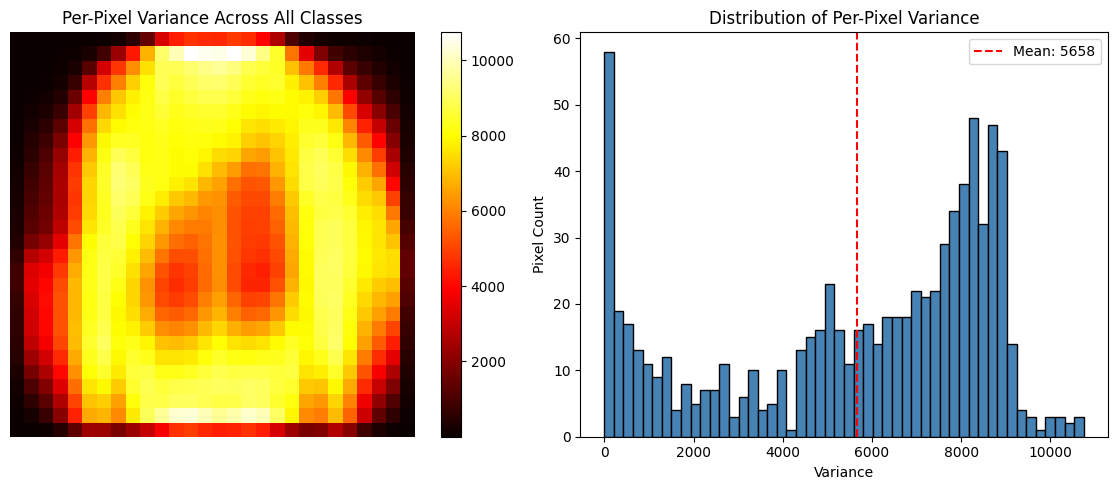

[6/6] Variance summary
  Near-zero variance pixels (<1.0): 5 / 784 (0.6%)
  Max variance: 10745.0 at position (np.int64(1), np.int64(15))
  Mean variance: 5657.9


In [6]:
# Step 6: Pixel variance heatmap

pixel_variance = X_train.astype(np.float32).var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Variance heatmap
im = axes[0].imshow(pixel_variance, cmap="hot")
axes[0].set_title("Per-Pixel Variance Across All Classes")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Histogram of variances
axes[1].hist(pixel_variance.flatten(), bins=50, color="steelblue", edgecolor="black")
axes[1].set_xlabel("Variance")
axes[1].set_ylabel("Pixel Count")
axes[1].set_title("Distribution of Per-Pixel Variance")
axes[1].axvline(pixel_variance.mean(), color="red", linestyle="--",
                label=f"Mean: {pixel_variance.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

zero_var = (pixel_variance < 1.0).sum()
print("=" * 60)
print("[6/6] Variance summary")
print("=" * 60)
print(f"  Near-zero variance pixels (<1.0): {zero_var} / 784 ({zero_var/784*100:.1f}%)")
print(f"  Max variance: {pixel_variance.max():.1f} at position {np.unravel_index(pixel_variance.argmax(), (28,28))}")
print(f"  Mean variance: {pixel_variance.mean():.1f}")

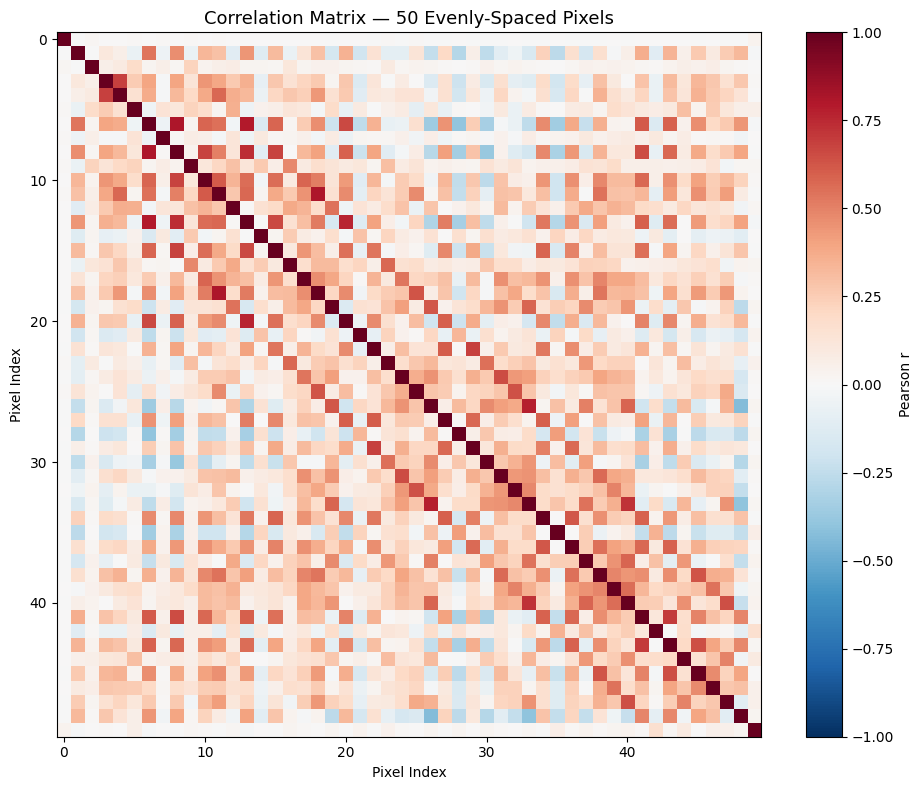

[7/7] Correlation summary (50 sampled pixels)
  Mean |r|: 0.190
  Pairs with |r| > 0.8: 2 / 1225
  Pairs with |r| > 0.5: 74 / 1225


In [7]:
# ============================================================
# Step 7: Feature correlation among sampled pixels
# ============================================================
# Flatten to (60000, 784) and sample 50 evenly-spaced pixels
X_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
pixel_indices = np.linspace(0, 783, 50, dtype=int)
X_sampled = X_flat[:, pixel_indices]

corr_matrix = np.corrcoef(X_sampled, rowvar=False)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — 50 Evenly-Spaced Pixels", fontsize=13)
ax.set_xlabel("Pixel Index")
ax.set_ylabel("Pixel Index")
plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
plt.tight_layout()
plt.show()

# Summarize correlation strength
upper_tri = corr_matrix[np.triu_indices(50, k=1)]
print("=" * 60)
print("[7/7] Correlation summary (50 sampled pixels)")
print("=" * 60)
print(f"  Mean |r|: {np.abs(upper_tri).mean():.3f}")
print(f"  Pairs with |r| > 0.8: {(np.abs(upper_tri) > 0.8).sum()} / {len(upper_tri)}")
print(f"  Pairs with |r| > 0.5: {(np.abs(upper_tri) > 0.5).sum()} / {len(upper_tri)}")

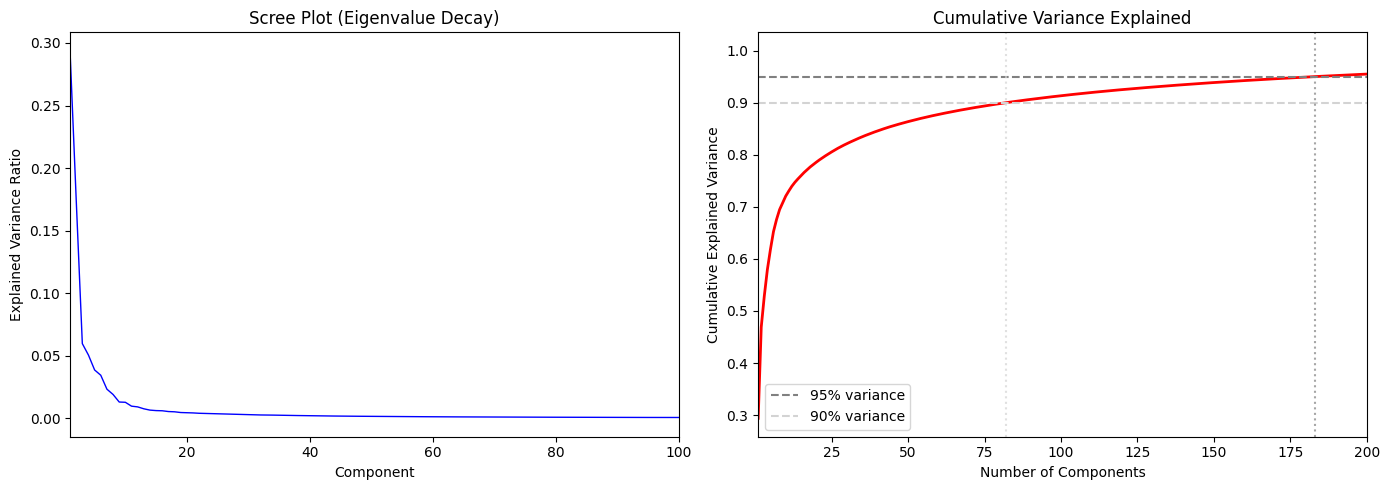

[8/8] Eigenvalue spectrum summary
  Components for 90% variance: 82
  Components for 95% variance: 183
  Top 10 components explain:   72.1%
  Top 50 components explain:   86.4%
  Compression ratio at 95%:    784 → 183 (23.3%)


In [8]:
# Step 8: Eigenvalue spectrum preview (quick SVD on subset)

# Use 10K samples for speed — enough to estimate eigenvalue decay
np.random.seed(113)
subset_idx = np.random.choice(len(X_flat), size=10000, replace=False)
X_subset = X_flat[subset_idx]

# Center the data (mean subtraction — standard PCA prerequisite)
X_centered = X_subset - X_subset.mean(axis=0)

# SVD to get singular values (eigenvalues = s^2 / (n-1))
_, s, _ = np.linalg.svd(X_centered, full_matrices=False)
eigenvalues = s ** 2 / (len(X_subset) - 1)
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(eigenvalues) + 1), explained_var_ratio, "b-", linewidth=1)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (Eigenvalue Decay)")
axes[0].set_xlim(1, 100)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, "r-", linewidth=2)
axes[1].axhline(0.95, color="gray", linestyle="--", label="95% variance")
axes[1].axhline(0.90, color="lightgray", linestyle="--", label="90% variance")

# Find components needed for thresholds
n_95 = np.searchsorted(cumulative_var, 0.95) + 1
n_90 = np.searchsorted(cumulative_var, 0.90) + 1
axes[1].axvline(n_95, color="gray", linestyle=":", alpha=0.7)
axes[1].axvline(n_90, color="lightgray", linestyle=":", alpha=0.7)

axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
axes[1].set_xlim(1, 200)

plt.tight_layout()
plt.show()

print("=" * 60)
print("[8/8] Eigenvalue spectrum summary")
print("=" * 60)
print(f"  Components for 90% variance: {n_90}")
print(f"  Components for 95% variance: {n_95}")
print(f"  Top 10 components explain:   {cumulative_var[9]:.1%}")
print(f"  Top 50 components explain:   {cumulative_var[49]:.1%}")
print(f"  Compression ratio at 95%:    784 → {n_95} ({n_95/784*100:.1f}%)")

## EDA Summary

### Key Findings
1. **Perfectly balanced**: 6,000 samples per class (train), 1,000 per class (test)
2. **Heavy zero-padding**: 50.2% of all pixels are zero (black background)
3. **High redundancy**: Adjacent pixels correlated; block structure in correlation matrix
4. **Variance concentrated in center**: Garment silhouette region has variance up to 10,745; corners near zero
5. **Strong eigenvalue decay**: Top 10 PCs explain 72.1%, 82 PCs for 90%, 183 PCs for 95%

### Preprocessing Implications
- **Flatten** 28×28 → 784 features
- **StandardScaler** required — pixel variances range from 0 to 10,745
- **No class balancing needed** — already perfectly balanced
- **Train/test split** — use the built-in 60K/10K split (no manual splitting)

### Pipeline Plan
- Test component counts: [10, 25, 50, 100, 150, 200]
- Evaluate intrinsically (explained variance, reconstruction error) and extrinsically (downstream classifier accuracy)
- Visualize reconstructions at different component counts to show compression quality